In [8]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from samplomatic import Twirl, build
from samplomatic.transpiler import generate_boxing_pass_manager


from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.quantum_program import QuantumProgram

import numpy as np

In [3]:
backend = QiskitRuntimeService().backend('ibm_kingston')

In [4]:
# Bell circuit
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cz(0, 1)
qc.measure(range(2), range(2))

# Qiskit native transpiler
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)

# Define the pass manager for twirling gates and measures
boxing_pass_manager = generate_boxing_pass_manager(
    enable_gates = True,
    enable_measures = True,
)
pm.post_scheduling = boxing_pass_manager

tqc = pm.run(qc)

template_circuit, samplex = build(tqc)

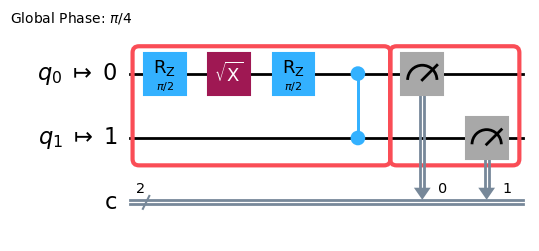

In [5]:
tqc.draw('mpl')

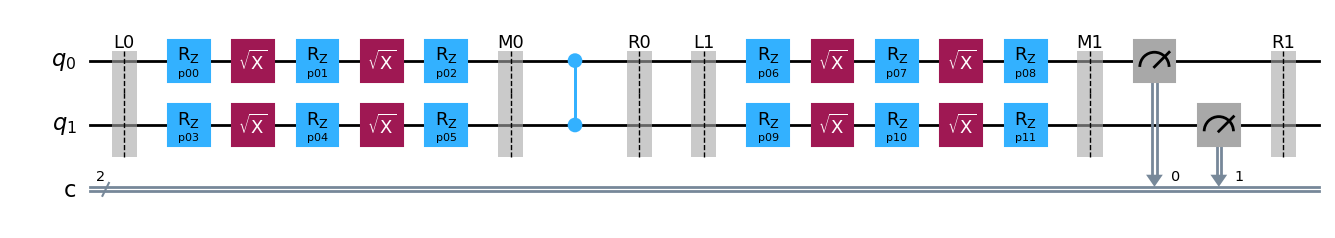

In [6]:
template_circuit.draw('mpl',idle_wires=False)

In [7]:
samplex.draw()

In [9]:
from qiskit_ibm_runtime.quantum_program import QuantumProgram
from qiskit_ibm_runtime.executor import Executor

In [10]:
program = QuantumProgram(shots=1024)
program.append_samplex_item(circuit=template_circuit, samplex=samplex, samplex_arguments={}, shape=(10,))

In [11]:
executor = Executor(mode=backend)
job = executor.run(program=program)

In [12]:
res = job.result()[0]

In [16]:
res_1 = res['c']
flips_1 = res['measurement_flips.c']

unflipped_result_1 = res_1 ^ flips_1

In [18]:
unflipped_result_1.shape

(10, 1024, 2)

In [21]:
flips_1.shape

(10, 1, 2)

In [11]:
from qiskit_ibm_runtime.quantum_program.quantum_program import CircuitItem


In [ ]:
import numpy as np

parametervalues = [np.random.uniform(low=0, high=np.pi/2, size = template_circuit.num_parameters) for _ in range(2)]

In [13]:
parametervalues

array([0.18479914, 1.53456206, 1.22197943, 0.12191397, 0.67247383,
       0.79364706, 1.44777019, 1.23963575, 0.54632076, 1.49789277,
       0.90936051, 0.34740005])

In [15]:
pubs= [CircuitItem(template_circuit, circuit_arguments=parametervalues)]

program = QuantumProgram(shots=1000, items=pubs)

In [24]:
# Generate a quantum program
program = QuantumProgram(shots=1000)

program.append_samplex_item(circuit=template_circuit,samplex=samplex,
                            shape = (10,))

In [16]:

from qiskit_ibm_runtime.executor import Executor

executor = Executor(mode=backend)
job = executor.run(program)

print(job.job_id())

d7tmhe4f3ras73b9e9q0


In [17]:
res = job.result()[0]

print(f"Twirl result keys:\n {list(res.keys())}\n")
print(f"Shape of results: {res['c'].shape}")


Twirl result keys:
 ['c']

Shape of results: (1000, 2)


In [31]:
import numpy as np

result_unflipped = res['c'] ^ res['measurement_flips.c']
exp_vals = 1 - 2*result_unflipped.mean(axis=1).mean(axis=0)

for qubit, val in enumerate(exp_vals):
    print(f"Qubit {qubit} -> {np.round(val, 2)}")

Qubit 0 -> 0.02
Qubit 1 -> 0.92
